# Preprocessing Data — Amir (LOF v2)

Rebuild preprocessing untuk pipeline **Local Outlier Factor (LOF)**, dari data mentah baru (`raw_data_master.csv`) sampai dataset siap model (`data_cleaned_v2.csv`).

Mengikuti spec: `docs/superpowers/specs/2026-09-12-lof-redo-design.md`.

**Enam aturan wajib kelompok yang harus dipenuhi:**
1. Jumlah baris tepat 1.715, **tanpa drop baris** di tahap manapun.
2. Urutan baris: `economy` ascending, lalu `year` ascending (1990–2024).
3. Fitur valuta wajib `Exchange_Depreciation` (% perubahan), bukan nominal mentah.
4. Prediksi biner: 1 = Anomali/Krisis, 0 = Normal (diterapkan di tahap modeling, bukan di sini).
5. Random seed dikunci 42 (diterapkan di tahap modeling yang punya proses acak).
6. Format output `hasil_lof_v2.csv` kolom `['economy','year','anomaly_score','predicted_anomaly']` (tahap modeling).

Notebook ini menangani aturan 1–3; aturan 4–6 berlaku di notebook modeling LOF berikutnya.

## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer

df = pd.read_csv('raw_data_master.csv')
df = df.sort_values(['economy', 'year']).reset_index(drop=True)
df['year'] = df['year'].astype('int64')

print(f'Shape: {df.shape}')
print(f'Jumlah negara: {df["economy"].nunique()}')
print(f'Rentang tahun: {df["year"].min()}-{df["year"].max()}')
print(df.head(3).to_string())

Shape: (1715, 16)
Jumlah negara: 49
Rentang tahun: 1990-2024
  economy  year  GDP_Growth  Inflation_CPI  Unemployment  Current_Account_GDP  Reserves_Months_Imports  Exchange_Rate  FDI_Inflows_GDP  Exports_GDP  Imports_GDP  Gross_Savings_GDP  Investment_GDP  Manufacturing_Value  Domestic_Credit_GDP  Broad_Money_Growth
0     ARE  1990   18.327723            NaN           NaN                  NaN                      NaN          3.671        -0.228436          NaN          NaN                NaN             NaN             7.494109                  NaN           -8.197759
1     ARE  1991    0.860104            NaN         1.629                  NaN                      NaN          3.671         0.050318          NaN          NaN                NaN             NaN             7.422869                  NaN           14.542822
2     ARE  1992    3.345282            NaN         1.715                  NaN                      NaN          3.671         0.239163          NaN          NaN     

## 2. Transformasi Fitur Valuta — `Exchange_Rate` -> `Exchange_Depreciation`

Aturan wajib #3: jangan masukkan nilai nominal kurs mentah (~15.000 Rupiah, ~24.000 Dong) ke model. Ubah jadi persen perubahan tahunan per negara.

In [2]:
n_countries = df['economy'].nunique()
n_raw_gaps = int(df['Exchange_Rate'].isna().sum())

df['Exchange_Depreciation'] = df.groupby('economy')['Exchange_Rate'].pct_change() * 100
df = df.drop(columns=['Exchange_Rate'])

n_dep_nan = int(df['Exchange_Depreciation'].isna().sum())
print(f"Shape setelah transform: {df.shape}")
print(f"'Exchange_Rate' masih ada di kolom: {'Exchange_Rate' in df.columns}")
print(f"NaN di Exchange_Depreciation: {n_dep_nan}")
print(f"  - {n_countries} wajar: tahun pertama tiap negara (tidak ada tahun sebelumnya untuk dihitung persen perubahannya)")
print(f"  - sisanya ({n_dep_nan - n_countries}) berasal dari {n_raw_gaps} gap asli di Exchange_Rate (CZE, LKA, RUS)")
print(f"    -- pct_change tidak bisa dihitung baik PADA baris yang kosong, maupun baris SESUDAHNYA (butuh nilai valid sebelumnya)")
print(f"  Semua NaN ini akan diisi oleh interpolasi per negara di langkah berikutnya, sama seperti fitur lain.")

Shape setelah transform: (1715, 16)
'Exchange_Rate' masih ada di kolom: False
NaN di Exchange_Depreciation: 59
  - 49 wajar: tahun pertama tiap negara (tidak ada tahun sebelumnya untuk dihitung persen perubahannya)
  - sisanya (10) berasal dari 9 gap asli di Exchange_Rate (CZE, LKA, RUS)
    -- pct_change tidak bisa dihitung baik PADA baris yang kosong, maupun baris SESUDAHNYA (butuh nilai valid sebelumnya)
  Semua NaN ini akan diisi oleh interpolasi per negara di langkah berikutnya, sama seperti fitur lain.


## 3. Analisis Missing Value (Level Fitur, Bukan Baris)

Broad_Money_Growth         25.0
Domestic_Credit_GDP        18.6
Gross_Savings_GDP           9.3
Manufacturing_Value         6.8
Reserves_Months_Imports     6.6
Current_Account_GDP         6.6
Investment_GDP              3.7
Exchange_Depreciation       3.4
Exports_GDP                 3.4
Inflation_CPI               3.4
Imports_GDP                 3.4
Unemployment                2.9
FDI_Inflows_GDP             0.3
GDP_Growth                  0.2


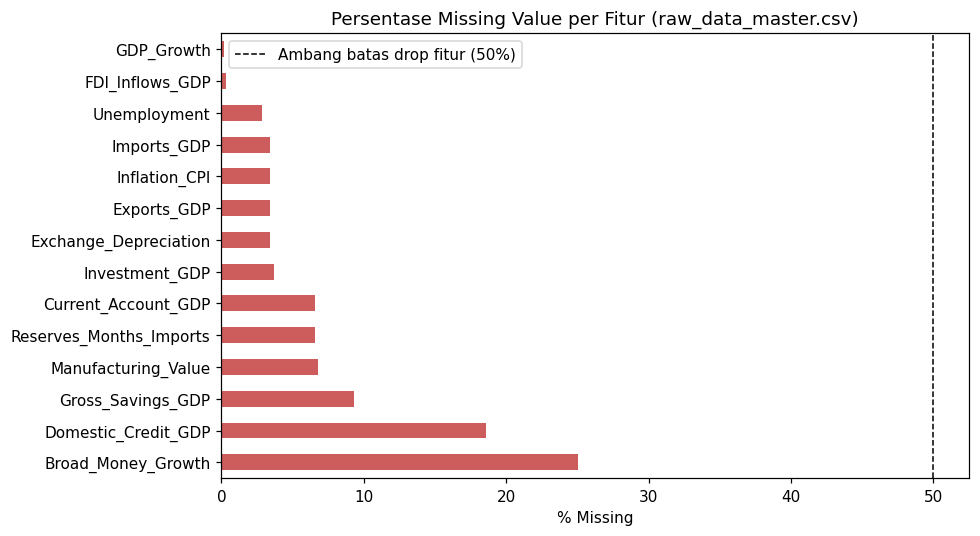

In [3]:
feature_cols = [c for c in df.columns if c not in ('economy', 'year')]
missing_pct = (df[feature_cols].isna().mean() * 100).sort_values(ascending=False)
print(missing_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
missing_pct.plot(kind='barh', ax=ax, color='indianred')
ax.axvline(50, color='black', linestyle='--', linewidth=1, label='Ambang batas drop fitur (50%)')
ax.set_xlabel('% Missing')
ax.set_title('Persentase Missing Value per Fitur (raw_data_master.csv)')
ax.legend()
plt.tight_layout()
plt.show()

### 3.1 Filter Level Fitur (>50% missing) — Tanpa Drop Baris

Aturan wajib #1: baris tidak boleh berkurang. Hanya kolom/fitur yang boleh dibuang, itupun kalau >50% kosong.

In [4]:
feature_thresh = 0.5
dropped_features = missing_pct[missing_pct / 100 > feature_thresh].index.tolist()
feature_cols = [c for c in feature_cols if c not in dropped_features]

print(f'Fitur di-drop (>50% missing): {dropped_features}')
print(f'Jumlah fitur tersisa: {len(feature_cols)}')
print(f'Jumlah baris saat ini (wajib tetap 1715): {len(df)}')
assert len(df) == 1715, 'Baris tidak boleh berkurang!'

Fitur di-drop (>50% missing): []
Jumlah fitur tersisa: 14
Jumlah baris saat ini (wajib tetap 1715): 1715


## 4. Interpolasi Linear per Negara

In [5]:
for col in feature_cols:
    df[col] = df.groupby('economy')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

remaining_nan = df[feature_cols].isna().sum()
remaining_nan = remaining_nan[remaining_nan > 0]
print('NaN tersisa per kolom setelah interpolasi per negara:')
print(remaining_nan.to_string() if len(remaining_nan) else '(tidak ada)')
print(f'Total NaN tersisa: {int(remaining_nan.sum())}')

NaN tersisa per kolom setelah interpolasi per negara:
Exports_GDP            35
Imports_GDP            35
Gross_Savings_GDP      35
Investment_GDP         35
Broad_Money_Growth    350
Total NaN tersisa: 490


### 4.1 Diagnostik: Pasangan (Negara, Fitur) Tanpa Data Sama Sekali

Interpolasi hanya gagal kalau satu negara sama sekali tidak punya data valid untuk satu indikator sepanjang 35 tahun.

In [6]:
fully_missing = []
for col in feature_cols:
    valid_counts = df.groupby('economy')[col].apply(lambda x: x.notna().sum())
    for econ in valid_counts[valid_counts == 0].index:
        fully_missing.append((econ, col))

print('Pasangan (negara, fitur) tanpa data valid sama sekali:')
for econ, col in fully_missing:
    print(f'  {econ:4s} - {col}')
print(f'Total: {len(fully_missing)} pasangan ({len(fully_missing) * 35} sel)')

Pasangan (negara, fitur) tanpa data valid sama sekali:
  NGA  - Exports_GDP
  NGA  - Imports_GDP
  NGA  - Gross_Savings_GDP
  NGA  - Investment_GDP
  AUT  - Broad_Money_Growth
  BEL  - Broad_Money_Growth
  DEU  - Broad_Money_Growth
  ESP  - Broad_Money_Growth
  FRA  - Broad_Money_Growth
  GRC  - Broad_Money_Growth
  IRL  - Broad_Money_Growth
  ITA  - Broad_Money_Growth
  NLD  - Broad_Money_Growth
  PRT  - Broad_Money_Growth
Total: 14 pasangan (490 sel)


## 5. Imputasi Sisa Missing — Median per Negara, lalu `KNNImputer` Fallback

In [7]:
median_by_country = df.groupby('economy')[feature_cols].transform('median')
df[feature_cols] = df[feature_cols].fillna(median_by_country)

remaining = int(df[feature_cols].isna().sum().sum())
print(f'NaN tersisa setelah median per negara: {remaining}')

if remaining > 0:
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])

final_remaining = int(df[feature_cols].isna().sum().sum())
print(f'NaN tersisa setelah KNNImputer fallback: {final_remaining}')
print(f'Jumlah baris (wajib tetap 1715): {len(df)}')
assert final_remaining == 0
assert len(df) == 1715

NaN tersisa setelah median per negara: 490
NaN tersisa setelah KNNImputer fallback: 0
Jumlah baris (wajib tetap 1715): 1715


## 6. Standarisasi — `RobustScaler`

Dipilih (bukan `StandardScaler`) karena LOF adalah metode berbasis jarak: `RobustScaler` pakai median/IQR sehingga tahan terhadap lonjakan ekstrem (hiperinflasi, devaluasi kurs mendadak seperti Argentina 2002 atau Rusia 1998).

In [8]:
scaler = RobustScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

print('Statistik fitur setelah RobustScaler (median mendekati 0):')
print(df[feature_cols].describe().T[['mean', 'std', 'min', 'max']].round(3).to_string())

Statistik fitur setelah RobustScaler (median mendekati 0):
                          mean     std     min       max
GDP_Growth              -0.010   0.967  -4.619     5.547
Inflation_CPI            2.855  37.158  -1.387  1307.678
Unemployment             0.257   0.987  -1.127     6.046
Current_Account_GDP      0.175   1.016  -3.468     4.867
Reserves_Months_Imports  0.229   1.106  -0.971     8.378
FDI_Inflows_GDP          0.475   2.567 -14.803    36.461
Exports_GDP              0.396   1.295  -0.970     8.331
Imports_GDP              0.368   1.261  -1.196     8.600
Gross_Savings_GDP        0.118   0.732  -1.662     2.622
Investment_GDP           0.142   0.898  -1.889     4.735
Manufacturing_Value      0.065   0.765  -1.521     2.804
Domestic_Credit_GDP      0.065   0.613  -0.839     1.897
Broad_Money_Growth       1.147  17.250  -5.084   599.523
Exchange_Depreciation    0.816   7.457 -10.585   194.516


## 7. `crisis_label` — Join Ground Truth Eksternal (IMF)

`crisis_label` dibangun terakhir, dari `ground_truth_imf.csv` (per negara-tahun, banking/currency/sovereign-debt crisis + COVID), bukan aturan enam-episode buatan sendiri. Tidak pernah menyentuh langkah manapun sebelumnya.

In [9]:
ground_truth = pd.read_csv('ground_truth_imf.csv')[['economy', 'year', 'is_crisis']]
df = df.merge(ground_truth, on=['economy', 'year'], how='left')

n_unmatched = int(df['is_crisis'].isna().sum())
assert n_unmatched == 0, f'Ada {n_unmatched} baris tanpa ground truth!'

df['crisis_label'] = df['is_crisis'].astype('int64')
df = df.drop(columns=['is_crisis'])

n_crisis = int(df['crisis_label'].sum())
print(f'Total baris: {len(df)}')
print(f'Baris crisis_label=1: {n_crisis} ({n_crisis / len(df):.1%})')

Total baris: 1715
Baris crisis_label=1: 229 (13.4%)


## 8. Verifikasi Akhir & Simpan

In [10]:
assert len(df) == 1715, 'Jumlah baris wajib tepat 1715'
assert list(df.columns[:2]) == ['economy', 'year']
assert df[feature_cols].isna().sum().sum() == 0
assert list(zip(df['economy'], df['year'])) == sorted(zip(df['economy'], df['year']))

print('=' * 60)
print('VERIFIKASI KEPATUHAN ATURAN WAJIB KELOMPOK')
print('=' * 60)
print(f'1. Jumlah baris tepat 1715, tanpa drop   : {len(df) == 1715}')
print(f'2. Urutan economy asc, year asc          : OK (diverifikasi)')
print(f'3. Exchange_Depreciation, bukan nominal  : OK ({"Exchange_Rate" not in df.columns})')
print(f'   Jumlah fitur akhir ({len(feature_cols)}) : {feature_cols}')
print(f'   crisis_label dari ground_truth_imf.csv : {n_crisis} baris ({n_crisis / len(df):.1%})')

df.to_csv('data_cleaned_v2.csv', index=False)
print('\nDisimpan ke data_cleaned_v2.csv')
print(df.head(3).to_string())

VERIFIKASI KEPATUHAN ATURAN WAJIB KELOMPOK
1. Jumlah baris tepat 1715, tanpa drop   : True
2. Urutan economy asc, year asc          : OK (diverifikasi)
3. Exchange_Depreciation, bukan nominal  : OK (True)
   Jumlah fitur akhir (14) : ['GDP_Growth', 'Inflation_CPI', 'Unemployment', 'Current_Account_GDP', 'Reserves_Months_Imports', 'FDI_Inflows_GDP', 'Exports_GDP', 'Imports_GDP', 'Gross_Savings_GDP', 'Investment_GDP', 'Manufacturing_Value', 'Domestic_Credit_GDP', 'Broad_Money_Growth', 'Exchange_Depreciation']
   crisis_label dari ground_truth_imf.csv : 229 baris (13.4%)

Disimpan ke data_cleaned_v2.csv
  economy  year  GDP_Growth  Inflation_CPI  Unemployment  Current_Account_GDP  Reserves_Months_Imports  FDI_Inflows_GDP  Exports_GDP  Imports_GDP  Gross_Savings_GDP  Investment_GDP  Manufacturing_Value  Domestic_Credit_GDP  Broad_Money_Growth  Exchange_Depreciation  crisis_label
0     ARE  1990    3.911886       1.532969     -0.833528             2.343188                   0.1765        -0

## Ringkasan Preprocessing

| Tahap | Metode | Alasan |
|---|---|---|
| Fitur valuta | `Exchange_Rate` -> `Exchange_Depreciation` (% YoY per negara) | Aturan wajib kelompok; nilai nominal antar-negara tidak sebanding |
| Filter missing | Drop fitur >50% missing (tidak ada yang kena); **tidak ada baris yang di-drop** | Wajib 1.715 baris agar sejajar dengan lima algoritma lain untuk majority voting |
| Imputasi | Interpolasi linear per negara -> median per negara -> `KNNImputer` fallback | Time-series per negara diinterpolasi dulu; `KNNImputer` menutup 14 pasangan (negara, fitur) yang sama sekali kosong sepanjang 35 tahun |
| Standarisasi | `RobustScaler` (median/IQR) | LOF berbasis jarak; tahan lonjakan ekstrem (devaluasi kurs, hiperinflasi) dibanding `StandardScaler` |
| `crisis_label` | Join `ground_truth_imf.csv` pada `(economy, year)`, diambil dari `is_crisis` | Ground truth eksternal (IMF-style), bukan aturan enam-episode buatan sendiri; dibangun **terakhir**, tidak pernah dipakai di langkah manapun sebelumnya |

**Output:** `Amir/data_cleaned_v2.csv` — 1.715 baris, 14 fitur terstandarisasi + `economy` + `year` + `crisis_label`, siap untuk tahap modeling LOF (label-free hyperparameter selection, lihat spec §5).